In [2]:
import numpy as np
from utilities import *

## Setup Hamiltonian

In [3]:
from functools import lru_cache
from scipy.sparse import coo_matrix, csr_matrix

def fixedN_basis(m: int, N: int):
    """List all m-tuples of nonnegative ints summing to N."""
    if m < 1: raise ValueError("m must be >= 1")
    if N < 0: raise ValueError("N must be >= 0")

    basis = []
    occ = [0]*m

    def rec(pos, remaining):
        if pos == m-1:
            occ[pos] = remaining
            basis.append(tuple(occ))
            return
        for n in range(remaining+1):
            occ[pos] = n
            rec(pos+1, remaining-n)

    rec(0, N)
    return basis

class FixedNBosons:
    """
    Fixed total photon number N across m modes.
    Basis: tuples (n1,...,nm) with sum=N.
    Operators: number-conserving hopping a_i^† a_j.
    """
    def __init__(self, m: int, N: int):
        self.m = m
        self.N = N
        self.basis = fixedN_basis(m, N)
        self.dim = len(self.basis)
        self.basis_to_index = {occ: i for i, occ in enumerate(self.basis)}

    def ket(self, occ):
        occ = tuple(occ)
        v = np.zeros(self.dim, dtype=complex)
        v[self.basis_to_index[occ]] = 1.0
        return v

    def pretty_ket(self, psi, tol=1e-12, max_terms=30):
        terms = [(i, amp, self.basis[i]) for i, amp in enumerate(psi) if abs(amp) > tol]
        terms.sort(key=lambda t: abs(t[1]), reverse=True)
        if not terms:
            return "0"
        lines = []
        for i, amp, occ in terms[:max_terms]:
            lines.append(f"{amp:+.6g} |{occ}>")
        if len(terms) > max_terms:
            lines.append(f"... ({len(terms)-max_terms} more terms)")
        return "\n".join(lines)

    def mean_occupations(self, psi):
        # <n_k> from probabilities in occupation basis
        p = np.abs(psi)**2
        nk = np.zeros(self.m, dtype=float)
        for idx, occ in enumerate(self.basis):
            nk += p[idx] * np.array(occ, dtype=float)
        return np.round(nk, 2)

    @lru_cache(maxsize=None)
    def hop(self, i: int, j: int) -> csr_matrix:
        """
        Return sparse matrix for a_i^† a_j (1-indexed modes).
        Acts within fixed-N subspace.
        """
        if not (1 <= i <= self.m and 1 <= j <= self.m):
            raise ValueError("mode indices must be in 1..m")
        if i == j:
            # This is number operator n_i
            rows, cols, data = [], [], []
            for col, occ in enumerate(self.basis):
                data.append(occ[i-1])
                rows.append(col)
                cols.append(col)
            return csr_matrix((data, (rows, cols)), shape=(self.dim, self.dim), dtype=complex)

        rows, cols, data = [], [], []
        for col, occ in enumerate(self.basis):
            nj = occ[j-1]
            if nj == 0:
                continue
            # new occupation: move one photon from j to i
            new_occ = list(occ)
            new_occ[j-1] -= 1
            new_occ[i-1] += 1
            new_occ = tuple(new_occ)
            row = self.basis_to_index[new_occ]

            amp = np.sqrt((occ[i-1] + 1) * occ[j-1])  # bosonic factor
            rows.append(row)
            cols.append(col)
            data.append(amp)

        return csr_matrix((data, (rows, cols)), shape=(self.dim, self.dim), dtype=complex)

In [4]:
hs = FixedNBosons(m=8, N=3)               # 3 photons over 8 modes
psi = hs.ket((3,0,0,0,0,0,0,0))           # all 3 photons in mode 1

print("Initial:")
print(hs.pretty_ket(psi))
print("<n_k> =", hs.mean_occupations(psi))

# Apply a_2^† a_1 : move one photon from mode 1 to mode 2
psi2 = hs.hop(2,1) @ psi
# Normalize if you want to interpret as a state after a non-unitary operator application
psi2 = psi2 / np.linalg.norm(psi2)
print("\nAfter hop (2 <- 1):")
print(hs.pretty_ket(psi2))
print("<n_k> =", hs.mean_occupations(psi2))


Initial:
+1+0j |(3, 0, 0, 0, 0, 0, 0, 0)>
<n_k> = [3. 0. 0. 0. 0. 0. 0. 0.]

After hop (2 <- 1):
+1+0j |(2, 1, 0, 0, 0, 0, 0, 0)>
<n_k> = [2. 1. 0. 0. 0. 0. 0. 0.]


## Second quantization ECM

In [5]:
from scipy.sparse.linalg import expm_multiply

def build_H_edges(hs, edges, eps=None):
    H = 0
    for i, j, Jij in edges:  # 1-indexed modes
        H = H + Jij * hs.hop(i, j) + np.conj(Jij) * hs.hop(j, i)
    if eps is not None:
        for i, ei in enumerate(eps, start=1):
            if ei != 0:
                H = H + ei * hs.hop(i, i)
    return H

def evolve(H, psi0, t):
    return expm_multiply((-1j * t) * H, psi0)

def layer_totals(nk):
    # modes 1-2 = L1, 3-4 = L2, 5-6 = L3
    return np.array([nk[0]+nk[1], nk[2]+nk[3], nk[4]+nk[5]])

def print_layers(label, hs, psi):
    nk = hs.mean_occupations(psi)  # unitary -> normalized
    print(f"{label:>10}  <L1,L2,L3> = {layer_totals(nk)}    <modes> = {nk}")

def K_from_edges(edges, src_modes, dst_modes):
    """
    Build the coupling matrix K (dst x src) from edges (src<->dst only).
    K[dst_index, src_index] = Jij for term a_dst^† a_src (with h.c. added in H builder).
    """
    src_to_col = {m: c for c, m in enumerate(src_modes)}
    dst_to_row = {m: r for r, m in enumerate(dst_modes)}
    K = np.zeros((len(dst_modes), len(src_modes)), dtype=complex)
    for i, j, Jij in edges:
        # interpret edge as undirected; decide orientation by membership
        if (i in src_to_col) and (j in dst_to_row):
            K[dst_to_row[j], src_to_col[i]] += Jij
        elif (j in src_to_col) and (i in dst_to_row):
            K[dst_to_row[i], src_to_col[j]] += Jij
    return K

def choose_time_from_K(K, method="rms"):
    s = np.linalg.svd(K, compute_uv=False)  # singular values
    s = np.sort(s)[::-1]                    # descending
    s_max = s[0]
    s_min = s[-1] if len(s) > 1 else s[0]
    s_rms = np.sqrt(np.mean(s**2))

    if method == "max":
        sigma = s_max
    elif method == "min":
        sigma = s_min
    elif method == "rms":
        sigma = s_rms
    else:
        raise ValueError("method must be one of: 'max', 'min', 'rms'")

    if sigma == 0:
        raise ValueError("All couplings are zero; cannot choose an interaction time.")
    return np.pi / (2 * sigma), s  # return time and the singular values

In [6]:
# ----------------------------
# Setup: 3 layers x 2 modes
# L1: (1,2), L2: (3,4), L3: (5,6)
# ----------------------------
m = 6
N = 2
hs = FixedNBosons(m=m, N=N)

# Initial: one photon per mode in layer 1 => |1,1,0,0,0,0>
psi0 = hs.ket((1,1,0,0,0,0))

# Different couplings between modes (interconnected, non-uniform)
edges12 = [(1,3, 1.0), (1,4, 0.3),
           (2,3, 0.2), (2,4, 0.9)]

edges23 = [(3,5, 0.7), (3,6, 0.2),
           (4,5, 0.4), (4,6, 1.1)]

H12 = build_H_edges(hs, edges12)
H23 = build_H_edges(hs, edges23)

# Choose non-greedy interaction times from coupling spectra
K12 = K_from_edges(edges12, src_modes=[1,2], dst_modes=[3,4])
K23 = K_from_edges(edges23, src_modes=[3,4], dst_modes=[5,6])

t1, s12 = choose_time_from_K(K12, method="rms")  # try "max"/"min"/"rms"
t2, s23 = choose_time_from_K(K23, method="rms")

print("Singular values K12:", s12, "=> t1 =", t1)
print("Singular values K23:", s23, "=> t2 =", t2)

# Evolve step-by-step
psi1 = evolve(H12, psi0, t1)
psi2 = evolve(H23, psi1, t2)

print_layers("initial", hs, psi0)
print_layers("after H12", hs, psi1)
print_layers("after H23", hs, psi2)

# Optional: see how populations change through "steps" by sampling around the chosen times
print("\nStep-1 sweep around t1 (just to observe, not to optimize):")
for frac in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]:
    psi_tmp = evolve(H12, psi0, frac*t1)
    print(f"t={frac*t1:7.3f}", layer_totals(hs.mean_occupations(psi_tmp)))

print("\nStep-2 sweep around t2 starting from psi1:")
for frac in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]:
    psi_tmp = evolve(H23, psi1, frac*t2)
    print(f"t={frac*t2:7.3f}", layer_totals(hs.mean_occupations(psi_tmp)))


Singular values K12: [1.20626586 0.6963639 ] => t1 = 1.5949020266171732
Singular values K23: [1.26609364 0.54498339] => t2 = 1.611603026826441
   initial  <L1,L2,L3> = [2. 0. 0.]    <modes> = [1. 1. 0. 0. 0. 0.]
 after H12  <L1,L2,L3> = [0.32 1.69 0.  ]    <modes> = [0.15 0.17 0.85 0.84 0.   0.  ]
 after H23  <L1,L2,L3> = [0.32 0.51 1.18]    <modes> = [0.15 0.17 0.3  0.21 0.56 0.62]

Step-1 sweep around t1 (just to observe, not to optimize):
t=  0.000 [2. 0. 0.]
t=  0.399 [1.71 0.28 0.  ]
t=  0.797 [1.05 0.95 0.  ]
t=  1.196 [0.47 1.53 0.  ]
t=  1.595 [0.32 1.69 0.  ]
t=  1.994 [0.58 1.42 0.  ]

Step-2 sweep around t2 starting from psi1:
t=  0.000 [0.32 1.69 0.  ]
t=  0.403 [0.32 1.44 0.25]
t=  0.806 [0.32 0.9  0.78]
t=  1.209 [0.32 0.51 1.17]
t=  1.612 [0.32 0.51 1.18]
t=  2.015 [0.32 0.77 0.92]


## Add ancilla atom detectors

In [7]:
from scipy.sparse import kron, identity, csr_matrix
from scipy.sparse.linalg import expm_multiply

In [8]:
def separate_subsystems(psi_full, dim_boson, dim_ancilla):
    """
    Given a joint state vector psi_full of dimension dim_boson*dim_ancilla,
    return the reduced density matrices for the bosonic and ancilla subsystems.
    If the state is a product state, also return the corresponding pure state
    vectors up to a global phase.

    Parameters
    ----------
    psi_full : 1D numpy array, shape (dim_boson*dim_ancilla,)
        The full state vector of the composite system.
    dim_boson : int
        Dimension of the bosonic subsystem.
    dim_ancilla : int
        Dimension of the ancilla subsystem (2 in your case).

    Returns
    -------
    rho_b : 2D numpy array, shape (dim_boson, dim_boson)
        Reduced density matrix of the bosonic subsystem.
    rho_a : 2D numpy array, shape (dim_ancilla, dim_ancilla)
        Reduced density matrix of the ancilla subsystem.
    psi_b : 1D numpy array or None
        Pure state vector of the bosonic subsystem if separable, else None.
    psi_a : 1D numpy array or None
        Pure state vector of the ancilla subsystem if separable, else None.
    """
    # reshape into matrix form (rows index boson states, columns index ancilla)
    psi_mat = psi_full.reshape(dim_boson, dim_ancilla)

    # reduced density matrices by partial trace
    rho_b = np.einsum('ik,jk->ij', psi_mat, psi_mat.conj())
    rho_a = np.einsum('ki,kj->ij', psi_mat, psi_mat.conj())

    # attempt to extract pure states if rank-1
    psi_b = None
    psi_a = None
    # eigen-decomposition of rho_b
    vals_b, vecs_b = np.linalg.eigh(rho_b)
    # find the eigenvector with the largest eigenvalue
    if np.isclose(vals_b[-1], 1.0, atol=1e-10):
        psi_b = vecs_b[:, -1]
        # similar for ancilla
        vals_a, vecs_a = np.linalg.eigh(rho_a)
        psi_a = vecs_a[:, -1]
        # fix global phase: make the inner product with psi_mat positive real
        phase = (psi_mat @ psi_a).conj().dot(psi_b)
        psi_b *= np.exp(-1j * np.angle(phase))
    return rho_b, rho_a, psi_b, psi_a

In [9]:
# ancilla Pauli matrices (dense, 2×2)
sigma_z = csr_matrix(np.array([[1, 0], [0, -1]], dtype=complex))
sigma_x = csr_matrix(np.array([[0, 1], [1, 0]], dtype=complex))
sigma_y = csr_matrix(np.array([[0, -1j], [1j, 0]], dtype=complex))
identity_qubit = csr_matrix(np.eye(2, dtype=complex))

In [10]:
hs = FixedNBosons(m=2, N=2)
H_boson = hs.hop(2, 1) + hs.hop(1, 2)  # simple hopping between two modes
psi_boson = hs.ket((2, 0))  # one photon in mode 1

In [11]:
# identities on bosonic space
identity_boson = identity(hs.dim, format='csr', dtype=complex)

In [12]:
# choose which mode to monitor (e.g., k=1) and its number operator
k = 1
n_k = hs.hop(k, k)  # this is a sparse operator acting on the bosonic Hilbert space

In [13]:
# dispersive parameters
chi = 0.05  # dispersive shift per photon (arbitrary units)
omega_q = 0.0  # qubit frequency; set to zero if you only care about the phase

In [14]:
# Build the full Hamiltonian on the tensor product space
H_boson_full = kron(H_boson, identity_qubit)
H_qubit_full = 0.5 * omega_q * kron(identity_boson, sigma_z)
H_disp = chi * kron(n_k, sigma_z)

In [15]:
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

In [16]:
t_hop = np.pi / (2 * 1.0)  # time to swap between modes 1 and 2
psi_full = np.kron(psi_boson, psi_anc_plus)  # initial state of boson + ancilla
psi_full_after_hop = expm_multiply((-1j * t_hop) * H_boson_full, psi_full)

In [17]:
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop, hs.dim, 2)

In [18]:
hs.mean_occupations(psi_b)

array([0., 2.])

In [19]:
def expectation_full_state(psi, O):
    """
    Expectation value <psi| O |psi>
    """
    return np.vdot(psi, O @ psi)

In [20]:
I_b = identity(hs.dim, format='csr', dtype=complex)

X_full = kron(I_b, sigma_x)
Y_full = kron(I_b, sigma_y)
Z_full = kron(I_b, sigma_z)

In [21]:
# apply int
N = 1  # max photon number 
t_int = 0.1 / (chi * N) 
psi_after_int = expm_multiply((-1j * t_int) * H_disp, psi_full_after_hop)

In [22]:
expectation_full_state(psi_after_int, Y_full)

np.complex128(1.8746159464641201e-31+0j)

In [23]:
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_after_int, hs.dim, 2)
hs.mean_occupations(psi_b)

array([0., 2.])

### compressed code for testing

In [24]:
# one layer bosonic ECM
m = 2
N = 3
hs = FixedNBosons(m=m, N=N)
H_boson = hs.hop(2, 1) + hs.hop(1, 2) 
identity_boson = identity(hs.dim, format='csr', dtype=complex) 
psi_boson = hs.ket((2, 1))  

# ancilla
k = 2 # monitor mode 2
n_k = hs.hop(k, k)
chi = 0.05
omega_q = 0.0
H_ancilla = 0.5 * omega_q * sigma_z 
identity_qubit = identity(2, format='csr', dtype=complex)
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

# total hamiltonians
H_int = chi * kron(n_k, sigma_z)
H_ecm = kron(H_boson, identity_qubit) + kron(identity_boson, H_ancilla)
psi_full = np.kron(psi_boson, psi_anc_plus)  # initial state of boson + ancilla

In [25]:
t_hop = np.pi / (2 * 1.0)  # time to swap between modes 1 and 2
psi_full = np.kron(psi_boson, psi_anc_plus)  # initial state of boson + ancilla
psi_full_after_hop = expm_multiply((-1j * t_hop) * H_ecm, psi_full)

# state before
print("Initial state, occupations numbers:", hs.mean_occupations(psi_boson))
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop, hs.dim, 2)
print("After hop, occupations numbers:", hs.mean_occupations(psi_b))

Initial state, occupations numbers: [2. 1.]
After hop, occupations numbers: [1. 2.]


In [26]:
t_int = 0.1 / (chi * 2)
psi_after_int = expm_multiply((-1j * t_int) * H_int, psi_full_after_hop)

In [27]:
Y_full = kron(identity_boson, sigma_y)

In [28]:
print("ancilla expectation <Y> after int:", np.real(np.round(expectation_full_state(psi_after_int, Y_full), 2) ))

ancilla expectation <Y> after int: 0.2


In [29]:
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_after_int, hs.dim, 2)
print("After int, occupations numbers:", hs.mean_occupations(psi_b))

After int, occupations numbers: [1. 2.]


## Multilayer with a few ancillas

In [30]:
# ----------------------------
# Setup: 3 layers x 2 modes
# L1: (1,2), L2: (3,4), L3: (5,6)
# ----------------------------
m = 6
N = 2
hs = FixedNBosons(m=m, N=N)

# Initial: one photon per mode in layer 1 => |1,1,0,0,0,0>
psi0 = hs.ket((1,1,0,0,0,0))

# Different couplings between modes (interconnected, non-uniform)
edges12 = [(1,3, 1.0), (1,4, 0.3),
           (2,3, 0.2), (2,4, 0.9)]

edges23 = [(3,5, 0.7), (3,6, 0.2),
           (4,5, 0.4), (4,6, 1.1)]

H12 = build_H_edges(hs, edges12)
H23 = build_H_edges(hs, edges23)

# Choose non-greedy interaction times from coupling spectra
K12 = K_from_edges(edges12, src_modes=[1,2], dst_modes=[3,4])
K23 = K_from_edges(edges23, src_modes=[3,4], dst_modes=[5,6])

t1, s12 = choose_time_from_K(K12, method="rms")  # try "max"/"min"/"rms"
t2, s23 = choose_time_from_K(K23, method="rms")

In [31]:
# dispersive parameters
chi = 0.05  # dispersive shift per photon (arbitrary units)
omega_q = 0.0  # qubit frequency; set to zero if you only care about the phase

In [32]:
# build ancillas
layers = [2]
modes_per_layer = {2: (3,4)}
H_ancilla = 0.5 * omega_q * sigma_z 
H_hop = {1:H12, 2:H23}
H_L_disp = {}
H_L_hop = {}
for l in layers:
    H_disp = csr_matrix(np.zeros((hs.dim*2**len(modes_per_layer[l]), (hs.dim*2**len(modes_per_layer[l]))), dtype=complex))  # placeholder for full Hamiltonian
    for i, k in enumerate(modes_per_layer[l]):
        # place sigma_z on the correct ancilla qubit
        if i == 0:
                sigma_z_full = sigma_z
        else:
            for j in range(i):
                if j == 0:
                    sigma_z_full = identity_qubit
                else:
                    sigma_z_full = kron(identity_qubit, sigma_z_full)
            sigma_z_full = kron(sigma_z, sigma_z_full)  # pad with identities for remaining ancillas
        for j in range(i+1, len(modes_per_layer[l])):
            sigma_z_full = kron(identity_qubit, sigma_z_full)
        n_k = hs.hop(k, k)
        H_disp += chi * kron(n_k, sigma_z_full) 
    H_L_disp[l] = H_disp
    H_ancillas = np.eye(2**len(modes_per_layer[l]), dtype=complex)
    H_L_hop[1] = kron(H_hop[1], H_ancillas)

In [33]:
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

In [34]:
psi_full = np.kron(psi0, np.kron(psi_anc_plus, psi_anc_plus))  # initial state of boson + ancillas
psi_full_after_hop1 = expm_multiply((-1j * t1) * H_L_hop[1], psi_full)

# state before
print("Initial state, occupations numbers:", hs.mean_occupations(psi0))
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop1, hs.dim, 2**len(modes_per_layer[2]))
print("After hop1, occupations numbers:", hs.mean_occupations(psi_b))

Initial state, occupations numbers: [1. 1. 0. 0. 0. 0.]
After hop1, occupations numbers: [0.15 0.17 0.85 0.84 0.   0.  ]


In [35]:
t_int = 0.1 / (chi * 2)
psi_after_int = expm_multiply((-1j * t_int) * H_L_disp[2], psi_full_after_hop1)

In [36]:
identity_boson = identity(hs.dim, format='csr', dtype=complex) 
Y_ancilla_1 = kron(identity_boson, kron(sigma_y, identity_qubit))  # Y on ancilla of layer 1
Y_ancilla_2 = kron(identity_boson, kron(identity_qubit, sigma_y))  # Y on ancilla of layer 2
print("ancilla 1 expectation <Y> after int:", np.real(np.round(expectation_full_state(psi_after_int, Y_ancilla_1), 2) ))
print("ancilla 2 expectation <Y> after int:", np.real(np.round(expectation_full_state(psi_after_int, Y_ancilla_2), 2) ))

ancilla 1 expectation <Y> after int: 0.08
ancilla 2 expectation <Y> after int: 0.08


In [37]:
hs.basis

[(0, 0, 0, 0, 0, 2),
 (0, 0, 0, 0, 1, 1),
 (0, 0, 0, 0, 2, 0),
 (0, 0, 0, 1, 0, 1),
 (0, 0, 0, 1, 1, 0),
 (0, 0, 0, 2, 0, 0),
 (0, 0, 1, 0, 0, 1),
 (0, 0, 1, 0, 1, 0),
 (0, 0, 1, 1, 0, 0),
 (0, 0, 2, 0, 0, 0),
 (0, 1, 0, 0, 0, 1),
 (0, 1, 0, 0, 1, 0),
 (0, 1, 0, 1, 0, 0),
 (0, 1, 1, 0, 0, 0),
 (0, 2, 0, 0, 0, 0),
 (1, 0, 0, 0, 0, 1),
 (1, 0, 0, 0, 1, 0),
 (1, 0, 0, 1, 0, 0),
 (1, 0, 1, 0, 0, 0),
 (1, 1, 0, 0, 0, 0),
 (2, 0, 0, 0, 0, 0)]

## try inequalities

In [38]:
# ----------------------------
# Setup: 3 layers x 2 modes
# L1: (1,2), L2: (3,4), L3: (5,6)
# ----------------------------
m = 6
N = 2
hs = FixedNBosons(m=m, N=N)

# Initial: one photon per mode in layer 1 => |1,1,0,0,0,0>
psi0 = hs.ket((1,1,0,0,0,0))

# Different couplings between modes (interconnected, non-uniform)
edges12 = [(1,3, 1.0), (1,4, 0.3),
           (2,3, 0.2), (2,4, 0.9)]

edges23 = [(3,5, 0.7), (3,6, 0.2),
           (4,5, 0.4), (4,6, 1.1)]

H12 = build_H_edges(hs, edges12)
H23 = build_H_edges(hs, edges23)

# Choose non-greedy interaction times from coupling spectra
K12 = K_from_edges(edges12, src_modes=[1,2], dst_modes=[3,4])
K23 = K_from_edges(edges23, src_modes=[3,4], dst_modes=[5,6])

t1, s12 = choose_time_from_K(K12, method="rms")  # try "max"/"min"/"rms"
t2, s23 = choose_time_from_K(K23, method="rms")

In [39]:
# dispersive parameters
chi = 0.05  # dispersive shift per photon (arbitrary units)
omega_q = 0.0  # qubit frequency; set to zero if you only care about the phase

In [40]:
# build ancillas
layers = [2]
modes_per_layer = {2: (3,4)}
H_ancilla = 0.5 * omega_q * sigma_z 
H_hop = {1:H12, 2:H23}
H_L_disp = {}
H_L_hop = {}
for l in layers:
    H_disp = csr_matrix(np.zeros((hs.dim*2**len(modes_per_layer[l]), (hs.dim*2**len(modes_per_layer[l]))), dtype=complex))  # placeholder for full Hamiltonian
    for i, k in enumerate(modes_per_layer[l]):
        # place sigma_z on the correct ancilla qubit
        if i == 0:
                sigma_z_full = sigma_z
        else:
            for j in range(i):
                if j == 0:
                    sigma_z_full = identity_qubit
                else:
                    sigma_z_full = kron(identity_qubit, sigma_z_full)
            sigma_z_full = kron(sigma_z, sigma_z_full)  # pad with identities for remaining ancillas
        for j in range(i+1, len(modes_per_layer[l])):
            sigma_z_full = kron(identity_qubit, sigma_z_full)
        n_k = hs.hop(k, k)
        H_disp += chi * kron(n_k, sigma_z_full) 
    H_L_disp[l] = H_disp
    H_ancillas = np.eye(2**len(modes_per_layer[l]), dtype=complex)
    H_L_hop[1] = kron(H_hop[1], H_ancillas)

In [41]:
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

In [42]:
psi_full = np.kron(psi0, np.kron(psi_anc_plus, psi_anc_plus))  # initial state of boson + ancillas
psi_full_after_hop1 = expm_multiply((-1j * t1) * H_L_hop[1], psi_full)

# state before
print("Initial state, occupations numbers:", hs.mean_occupations(psi0))
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop1, hs.dim, 2**len(modes_per_layer[2]))
print("After hop1, occupations numbers:", hs.mean_occupations(psi_b))

Initial state, occupations numbers: [1. 1. 0. 0. 0. 0.]
After hop1, occupations numbers: [0.15 0.17 0.85 0.84 0.   0.  ]


In [43]:
t_int = 0.1 / (chi * 2)
psi_after_int = expm_multiply((-1j * t_int) * H_L_disp[2], psi_full_after_hop1)

In [56]:
# ============================================================
# Stable fidelity utilities
# ============================================================

def psd_sqrt(rho, tol=1e-12):
    """
    Positive-semidefinite square root, stable for singular density matrices.
    """
    rho = np.asarray(rho, dtype=complex)
    rho = 0.5 * (rho + rho.conj().T)

    vals, vecs = np.linalg.eigh(rho)
    vals = np.clip(vals.real, 0.0, None)

    return vecs @ np.diag(np.sqrt(vals)) @ vecs.conj().T


def fidelity_dm(rho, sigma, tol=1e-12):
    """
    Uhlmann fidelity F(rho, sigma), not squared.
    """
    rho = np.asarray(rho, dtype=complex)
    sigma = np.asarray(sigma, dtype=complex)

    rho = 0.5 * (rho + rho.conj().T)
    sigma = 0.5 * (sigma + sigma.conj().T)

    sqrt_rho = psd_sqrt(rho, tol=tol)
    inner = sqrt_rho @ sigma @ sqrt_rho
    sqrt_inner = psd_sqrt(inner, tol=tol)

    F = np.real(np.trace(sqrt_inner))
    return float(np.clip(F, 0.0, 1.0))


# ============================================================
# Configuration helpers
# ============================================================

def local_config(occ, layer_modes):
    """
    Extract occupations on selected 1-indexed layer modes.

    Example:
        occ = (1,0,0,1,0,0), layer_modes=(3,4) -> (0,1)
    """
    return tuple(occ[m - 1] for m in layer_modes)


def env_config(occ, layer_modes):
    """
    Extract occupations on all modes except selected 1-indexed layer modes.
    """
    layer_set = {m - 1 for m in layer_modes}
    return tuple(n for i, n in enumerate(occ) if i not in layer_set)


def joint_matrix_from_state(psi_full, hs, dim_ancilla):
    """
    Convert |Psi> in H_photons ⊗ H_ancillas into a matrix

        Psi[photonic_basis_index, ancilla_basis_index].

    This matches your notebook construction:
        psi_full = np.kron(psi_photonic, psi_ancilla)
    """
    psi_full = np.asarray(psi_full, dtype=complex).reshape(-1)
    return psi_full.reshape(hs.dim, dim_ancilla)


# ============================================================
# Reduced photonic state on selected layer modes
# ============================================================

def reduced_layer_state_from_joint_pure(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes=(3, 4),
):
    """
    Given psi_full in H_photons ⊗ H_ancillas, compute rho_L for the selected
    layer modes by tracing out all other photonic modes and all ancillas.

    If layer_modes=(1,2,3,4,5,6), this returns the full photonic state
    rho_phot = Tr_A |Psi><Psi|.
    """
    Psi = joint_matrix_from_state(psi_full, hs, dim_ancilla)

    configs = sorted({local_config(occ, layer_modes) for occ in hs.basis})
    cfg_to_idx = {cfg: i for i, cfg in enumerate(configs)}

    # Trace out ancillas to get full photonic density matrix.
    rho_phot = Psi @ Psi.conj().T

    labels = [
        (local_config(occ, layer_modes), env_config(occ, layer_modes))
        for occ in hs.basis
    ]

    rho_layer = np.zeros((len(configs), len(configs)), dtype=complex)

    # Trace out all photonic modes outside layer_modes.
    for a, (mu_a, env_a) in enumerate(labels):
        i = cfg_to_idx[mu_a]
        for b, (mu_b, env_b) in enumerate(labels):
            if env_a == env_b:
                j = cfg_to_idx[mu_b]
                rho_layer[i, j] += rho_phot[a, b]

    # Numerical cleanup and normalization.
    rho_layer = 0.5 * (rho_layer + rho_layer.conj().T)
    tr = np.trace(rho_layer)
    if abs(tr) <= 1e-14:
        raise ValueError("Reduced layer state has near-zero trace.")
    rho_layer = rho_layer / tr

    probs = {
        cfg: float(np.real(rho_layer[cfg_to_idx[cfg], cfg_to_idx[cfg]]))
        for cfg in configs
    }

    return rho_layer, configs, probs


# ============================================================
# Active-support coherence
# ============================================================

def normalized_l1_coherence_active(
    rho_layer,
    configs,
    probs,
    p_tol=1e-14,
):
    """
    Active-support normalized l1 coherence:

        C = 1/(R_active - 1) sum_{mu != nu in active} |rho_mu,nu|.

    This must be used together with D_A, because D_A also restricts to
    active configurations.
    """
    active = [
        mu for mu in configs
        if probs.get(mu, 0.0) > p_tol
    ]

    R = len(active)
    if R <= 1:
        return 0.0, active

    idx = {cfg: i for i, cfg in enumerate(configs)}

    total = 0.0
    for mu in active:
        i = idx[mu]
        for nu in active:
            if mu == nu:
                continue
            j = idx[nu]
            total += abs(rho_layer[i, j])

    C = total / (R - 1)
    return float(C), active


# ============================================================
# Ancilla states conditioned on selected photonic configurations
# ============================================================

def conditioned_ancilla_states_from_layer_configs(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes=(3, 4),
    p_tol=1e-14,
):
    """
    For each selected local configuration mu, compute

        rho_A^mu =
            Tr_phot[(Pi_mu ⊗ I_A)|Psi><Psi|(Pi_mu ⊗ I_A)] / p_mu.

    Assumes psi_full is ordered as H_photons ⊗ H_ancillas.
    """
    Psi = joint_matrix_from_state(psi_full, hs, dim_ancilla)

    configs = sorted({local_config(occ, layer_modes) for occ in hs.basis})
    ancilla_states = {}
    probs = {}

    for mu in configs:
        rows = [
            idx for idx, occ in enumerate(hs.basis)
            if local_config(occ, layer_modes) == mu
        ]

        # Project onto local configuration mu, then trace out photons.
        block = Psi[rows, :]
        rho_A_unnorm = block.conj().T @ block

        p_mu = float(np.real(np.trace(rho_A_unnorm)))
        probs[mu] = p_mu

        if p_mu > p_tol:
            ancilla_states[mu] = rho_A_unnorm / p_mu

    return ancilla_states, probs, configs


# ============================================================
# Ancilla information term
# ============================================================

def ancilla_information_term_from_fidelities(
    ancilla_states,
    probs,
    configs,
    p_tol=1e-14,
):
    """
    Detector/ancilla information term:

        D_A =
            1 - 1/(R_active - 1)
                sum_{mu != nu in active}
                sqrt(p_mu p_nu) F(rho_A^mu, rho_A^nu).

    The corresponding bound is:

        C + D_A <= 1,

    provided C is computed over the same active configuration set.
    """
    active = [
        mu for mu in configs
        if probs.get(mu, 0.0) > p_tol and mu in ancilla_states
    ]

    R = len(active)
    if R <= 1:
        return {
            "D_A": 0.0,
            "overlap_term": 0.0,
            "active_configs": active,
            "pairwise_fidelities": {},
            "message": "Only one active configuration."
        }

    weighted_overlap_sum = 0.0
    pairwise_fidelities = {}

    for mu in active:
        for nu in active:
            if mu == nu:
                continue

            F = fidelity_dm(ancilla_states[mu], ancilla_states[nu])
            pairwise_fidelities[(mu, nu)] = F
            weighted_overlap_sum += np.sqrt(probs[mu] * probs[nu]) * F

    overlap_term = weighted_overlap_sum / (R - 1)
    D_A = 1.0 - overlap_term

    return {
        "D_A": float(np.clip(D_A, 0.0, 1.0)),
        "overlap_term": float(overlap_term),
        "active_configs": active,
        "pairwise_fidelities": pairwise_fidelities,
    }


# ============================================================
# Main diagnostic
# ============================================================

def wp_layer_diagnostic(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes=(3, 4),
    p_tol=1e-14,
):
    """
    Compute the layer/full-space coherence-path-information diagnostic:

        C + D_A <= 1.

    layer_modes:
        (3,4)               -> local middle-layer diagnostic.
        (1,2,3,4,5,6)       -> full photonic-space diagnostic.
    """
    rho_layer, configs, probs = reduced_layer_state_from_joint_pure(
        psi_full=psi_full,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=layer_modes,
    )

    ancilla_states, probs_A, configs_A = conditioned_ancilla_states_from_layer_configs(
        psi_full=psi_full,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=layer_modes,
        p_tol=p_tol,
    )

    # Sanity check: probabilities from rho_layer and from conditioning should match.
    max_prob_diff = max(
        abs(probs.get(cfg, 0.0) - probs_A.get(cfg, 0.0))
        for cfg in configs
    )

    C, active_configs = normalized_l1_coherence_active(
        rho_layer=rho_layer,
        configs=configs,
        probs=probs,
        p_tol=p_tol,
    )

    D_info = ancilla_information_term_from_fidelities(
        ancilla_states=ancilla_states,
        probs=probs_A,
        configs=configs_A,
        p_tol=p_tol,
    )

    D_A = D_info["D_A"]
    C_plus_D = C + D_A

    return {
        "layer_modes": layer_modes,
        "rho_layer": rho_layer,
        "configs": configs,
        "probabilities": probs,
        "conditioned_ancilla_states": ancilla_states,
        "active_configs": active_configs,
        "number_configs_total": len(configs),
        "number_configs_active": len(active_configs),
        "C": C,
        "D_A": D_A,
        "C_plus_D": C_plus_D,
        "slack": 1.0 - C_plus_D,
        "overlap_term": D_info["overlap_term"],
        "pairwise_fidelities": D_info["pairwise_fidelities"],
        "max_probability_difference_check": max_prob_diff,
    }


# ============================================================
# Decomposition details
# ============================================================

def decompose_duality_details(
    rho,
    ancilla_states,
    probs,
    configs,
    p_tol=1e-14,
    top_k=10,
):
    """
    Detailed decomposition of

        C + D_A <= 1.

    Returns:
      - prior/topology imbalance contribution,
      - detector distinguishability contribution,
      - pairwise contributions.
    """
    active = [
        mu for mu in configs
        if probs.get(mu, 0.0) > p_tol and mu in ancilla_states
    ]

    R = len(active)
    if R <= 1:
        return {
            "summary": {
                "R_active": R,
                "message": "Only one active configuration."
            },
            "all_pairs": [],
        }

    idx = {cfg: i for i, cfg in enumerate(configs)}

    pair_rows = []

    C_sum = 0.0
    Cmax_sum = 0.0
    prior_overlap_sum = 0.0
    detector_loss_sum = 0.0

    for mu in active:
        i = idx[mu]
        for nu in active:
            if mu == nu:
                continue

            j = idx[nu]

            p_mu = probs[mu]
            p_nu = probs[nu]
            sqrt_pp = np.sqrt(p_mu * p_nu)

            F = fidelity_dm(ancilla_states[mu], ancilla_states[nu])

            actual = abs(rho[i, j])
            allowed = sqrt_pp * F
            prior_allowed = sqrt_pp
            detector_loss = sqrt_pp * (1.0 - F)
            pair_slack = allowed - actual

            C_sum += actual
            Cmax_sum += allowed
            prior_overlap_sum += prior_allowed
            detector_loss_sum += detector_loss

            # Store unordered pairs once for display.
            if str(mu) < str(nu):
                pair_rows.append({
                    "mu": mu,
                    "nu": nu,
                    "p_mu": p_mu,
                    "p_nu": p_nu,
                    "sqrt_pp": sqrt_pp,
                    "F": F,
                    "actual_abs_rho": actual,
                    "allowed_sqrtppF": allowed,
                    "pair_slack": pair_slack,
                    "detector_loss": detector_loss,
                })

    norm = R - 1

    C = C_sum / norm
    Cmax = Cmax_sum / norm
    D_A = 1.0 - Cmax

    prior_overlap = prior_overlap_sum / norm
    D_prior = 1.0 - prior_overlap

    detector_loss = detector_loss_sum / norm

    summary = {
        "R_active": R,
        "C": float(C),
        "Cmax_allowed_by_ancillas": float(Cmax),
        "D_A": float(D_A),
        "C_plus_D": float(C + D_A),
        "slack": float(Cmax - C),
        "prior_overlap": float(prior_overlap),
        "D_prior_population_imbalance": float(D_prior),
        "D_detector_from_fidelity_loss": float(detector_loss),
        "check_DA_equals_prior_plus_detector": float(D_prior + detector_loss),
    }

    return {
        "summary": summary,
        "top_by_probability_weight": sorted(pair_rows, key=lambda r: r["sqrt_pp"], reverse=True)[:top_k],
        "top_by_detector_loss": sorted(pair_rows, key=lambda r: r["detector_loss"], reverse=True)[:top_k],
        "top_by_actual_coherence": sorted(pair_rows, key=lambda r: r["actual_abs_rho"], reverse=True)[:top_k],
        "top_by_slack": sorted(pair_rows, key=lambda r: r["pair_slack"], reverse=True)[:top_k],
        "all_pairs": pair_rows,
    }


def print_wp_diagnostic(diag, label="WP diagnostic"):
    """
    Compact printout for wp_layer_diagnostic output.
    """
    print(f"\n{label}")
    print("-" * len(label))
    print("layer modes:", diag["layer_modes"])
    print("number configs total:", diag["number_configs_total"])
    print("number configs active:", diag["number_configs_active"])
    print("C:", diag["C"])
    print("D_A:", diag["D_A"])
    print("C + D_A:", diag["C_plus_D"])
    print("slack:", diag["slack"])
    print("overlap term:", diag["overlap_term"])
    print("max probability difference check:", diag["max_probability_difference_check"])
    print("active configs:")
    for cfg in diag["active_configs"]:
        print(f"  {cfg}: p={diag['probabilities'][cfg]:.8f}")

In [57]:
diag_L2 = wp_layer_diagnostic(
    psi_full=psi_after_int,
    hs=hs,
    dim_ancilla=4,
    layer_modes=(3, 4),
)

print_wp_diagnostic(diag_L2, label="Local middle-layer diagnostic L2=(3,4)")


Local middle-layer diagnostic L2=(3,4)
--------------------------------------
layer modes: (3, 4)
number configs total: 6
number configs active: 6
C: 0.05267016220772043
D_A: 0.5165153146743735
C + D_A: 0.569185476882094
slack: 0.430814523117906
overlap term: 0.48348468532562655
max probability difference check: 9.992007221626409e-16
active configs:
  (0, 0): p=0.02641196
  (0, 1): p=0.11975024
  (0, 2): p=0.00790582
  (1, 0): p=0.14421639
  (1, 1): p=0.70044009
  (2, 0): p=0.00127550


In [58]:
diag_full = wp_layer_diagnostic(
    psi_full=psi_after_int,
    hs=hs,
    dim_ancilla=4,
    layer_modes=(1, 2, 3, 4, 5, 6),
)

print_wp_diagnostic(diag_full, label="Full six-mode photonic diagnostic")


Full six-mode photonic diagnostic
---------------------------------
layer modes: (1, 2, 3, 4, 5, 6)
number configs total: 21
number configs active: 10
C: 0.38398048218983516
D_A: 0.6160195147481181
C + D_A: 0.9999999969379533
slack: 3.062046727286827e-09
overlap term: 0.3839804852518819
max probability difference check: 9.992007221626409e-16
active configs:
  (0, 0, 0, 2, 0, 0): p=0.00790582
  (0, 0, 1, 1, 0, 0): p=0.70044009
  (0, 0, 2, 0, 0, 0): p=0.00127550
  (0, 1, 0, 1, 0, 0): p=0.11475855
  (0, 1, 1, 0, 0, 0): p=0.02120366
  (0, 2, 0, 0, 0, 0): p=0.00631610
  (1, 0, 0, 1, 0, 0): p=0.00499169
  (1, 0, 1, 0, 0, 0): p=0.12301272
  (1, 1, 0, 0, 0, 0): p=0.01940557
  (2, 0, 0, 0, 0, 0): p=0.00069029


In [59]:
details_full = decompose_duality_details(
    rho=diag_full["rho_layer"],
    ancilla_states=diag_full["conditioned_ancilla_states"],
    probs=diag_full["probabilities"],
    configs=diag_full["configs"],
    top_k=10,
)

print("\nFULL-SPACE DECOMPOSITION")
for k, v in details_full["summary"].items():
    print(f"{k}: {v}")

print("\nTop pairs by detector contribution:")
for row in details_full["top_by_detector_loss"]:
    print(
        row["mu"], row["nu"],
        "sqrt_pp=", f"{row['sqrt_pp']:.5f}",
        "F=", f"{row['F']:.6f}",
        "detector_loss=", f"{row['detector_loss']:.8f}",
    )


FULL-SPACE DECOMPOSITION
R_active: 10
C: 0.38398048218983516
Cmax_allowed_by_ancillas: 0.3839804852518823
D_A: 0.6160195147481178
C_plus_D: 0.9999999969379529
slack: 3.0620471158648854e-09
prior_overlap: 0.3846746279698745
D_prior_population_imbalance: 0.6153253720301255
D_detector_from_fidelity_loss: 0.0006941427179921103
check_DA_equals_prior_plus_detector: 0.6160195147481176

Top pairs by detector contribution:
(0, 0, 1, 1, 0, 0) (1, 0, 1, 0, 0, 0) sqrt_pp= 0.29354 F= 0.998750 detector_loss= 0.00036684
(0, 0, 1, 1, 0, 0) (0, 1, 0, 1, 0, 0) sqrt_pp= 0.28352 F= 0.998750 detector_loss= 0.00035432
(0, 1, 0, 1, 0, 0) (1, 0, 1, 0, 0, 0) sqrt_pp= 0.11881 F= 0.997502 detector_loss= 0.00029679
(0, 0, 1, 1, 0, 0) (1, 1, 0, 0, 0, 0) sqrt_pp= 0.11659 F= 0.997502 detector_loss= 0.00029122
(0, 0, 0, 2, 0, 0) (1, 0, 1, 0, 0, 0) sqrt_pp= 0.03119 F= 0.993761 detector_loss= 0.00019457
(0, 0, 0, 2, 0, 0) (0, 0, 1, 1, 0, 0) sqrt_pp= 0.07441 F= 0.997502 detector_loss= 0.00018588
(0, 0, 1, 1, 0, 0) (0, 

## Turn off interactions and test topology

In [60]:
psi_after_int = psi_full_after_hop1

In [65]:
# ============================================================
# Experiment 1: topology/connectivity sweep with ancillas off
# ============================================================

def build_hop_with_passive_ancillas(hs, edges12, dim_ancilla=4):
    """
    Build H12 on the photonic space and lift it to photons ⊗ ancillas.
    Ancillas are passive here.
    """
    H12 = build_H_edges(hs, edges12)
    I_A = identity(dim_ancilla, format="csr", dtype=complex)
    return H12, kron(H12, I_A)


def initial_full_state_with_two_plus_ancillas(psi0):
    """
    Assumes two qubit ancillas initialized in |+>|+>.
    """
    psi_plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
    psi_A = np.kron(psi_plus, psi_plus)
    return np.kron(psi0, psi_A)


def run_topology_case(
    name,
    edges12_case,
    hs,
    psi0,
    time_method="rms",
    dim_ancilla=4,
    p_tol=1e-14,
):
    """
    One topology case:
      - build K12
      - choose its own t1
      - evolve with passive ancillas
      - compute local and full WP diagnostics
    """
    K12 = K_from_edges(edges12_case, src_modes=[1, 2], dst_modes=[3, 4])
    t1_case, singular_values = choose_time_from_K(K12, method=time_method)

    H12_case, H12_full_case = build_hop_with_passive_ancillas(
        hs=hs,
        edges12=edges12_case,
        dim_ancilla=dim_ancilla,
    )

    psi_full0 = initial_full_state_with_two_plus_ancillas(psi0)

    # Ancillas off: only hopping evolution.
    psi_full_after_hop1 = expm_multiply(
        (-1j * t1_case) * H12_full_case,
        psi_full0,
    )

    # No dispersive interaction.
    psi_after_int_case = psi_full_after_hop1

    # Local middle-layer diagnostic.
    diag_L2 = wp_layer_diagnostic(
        psi_full=psi_after_int_case,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(3, 4),
        p_tol=p_tol,
    )

    # Full six-mode photonic diagnostic.
    diag_full = wp_layer_diagnostic(
        psi_full=psi_after_int_case,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(1, 2, 3, 4, 5, 6),
        p_tol=p_tol,
    )

    # Decompose full diagnostic into prior/topology vs detector.
    details_full = decompose_duality_details(
        rho=diag_full["rho_layer"],
        ancilla_states=diag_full["conditioned_ancilla_states"],
        probs=diag_full["probabilities"],
        configs=diag_full["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    # Decompose local diagnostic too.
    details_L2 = decompose_duality_details(
        rho=diag_L2["rho_layer"],
        ancilla_states=diag_L2["conditioned_ancilla_states"],
        probs=diag_L2["probabilities"],
        configs=diag_L2["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    # Photonic occupations, tracing out ancillas.
    Psi = joint_matrix_from_state(psi_after_int_case, hs, dim_ancilla)
    rho_phot = Psi @ Psi.conj().T
    # hs.mean_occupations expects a pure vector, so use diagonal probabilities manually.
    probs_phot = np.real(np.diag(rho_phot))
    nk = np.zeros(hs.m, dtype=float)
    for idx, occ in enumerate(hs.basis):
        nk += probs_phot[idx] * np.array(occ, dtype=float)

    return {
        "name": name,
        "edges12": edges12_case,
        "K12": K12,
        "singular_values": singular_values,
        "t1": t1_case,
        "mode_occupations": nk,
        "layer_occupations": np.array([nk[0] + nk[1], nk[2] + nk[3], nk[4] + nk[5]]),
        "diag_L2": diag_L2,
        "diag_full": diag_full,
        "details_L2": details_L2,
        "details_full": details_full,
    }


def _safe_summary_value(summary, key, default=np.nan):
    return summary[key] if key in summary else default


def summarize_topology_results(results):
    """
    Print compact comparison table, robust to cases with only one active configuration.
    """
    print(
        f"{'case':<16} {'t1':>8} "
        f"{'<L1>':>8} {'<L2>':>8} {'<L3>':>8} "
        f"{'R_L2':>6} {'C_L2':>10} {'Dprior_L2':>12} {'Ddet_L2':>10} {'slack_L2':>10} "
        f"{'R_full':>7} {'C_full':>10} {'Dprior_full':>13} {'Ddet_full':>11} {'slack_full':>11}"
    )

    for res in results:
        sL = res["details_L2"]["summary"]
        sF = res["details_full"]["summary"]
        L = res["layer_occupations"]

        print(
            f"{res['name']:<16} {res['t1']:8.4f} "
            f"{L[0]:8.4f} {L[1]:8.4f} {L[2]:8.4f} "
            f"{_safe_summary_value(sL, 'R_active', 0):6.0f} "
            f"{_safe_summary_value(sL, 'C'):10.4f} "
            f"{_safe_summary_value(sL, 'D_prior_population_imbalance'):12.4f} "
            f"{_safe_summary_value(sL, 'D_detector_from_fidelity_loss'):10.4e} "
            f"{_safe_summary_value(sL, 'slack'):10.4f} "
            f"{_safe_summary_value(sF, 'R_active', 0):7.0f} "
            f"{_safe_summary_value(sF, 'C'):10.4f} "
            f"{_safe_summary_value(sF, 'D_prior_population_imbalance'):13.4f} "
            f"{_safe_summary_value(sF, 'D_detector_from_fidelity_loss'):11.4e} "
            f"{_safe_summary_value(sF, 'slack'):11.4e}"
        )

        if "message" in sL:
            print(f"    local L2 note: {sL['message']}")
        if "message" in sF:
            print(f"    full-space note: {sF['message']}")

In [63]:
# ============================================================
# Define topology cases
# ============================================================

J = 1.0

topology_cases = {
    "baseline": [
        (1, 3, 1.0), (1, 4, 0.3),
        (2, 3, 0.2), (2, 4, 0.9),
    ],

    # Only matching channels.
    "diagonal": [
        (1, 3, J),
        (2, 4, J),
    ],

    # Only crossed channels.
    "crossed": [
        (1, 4, J),
        (2, 3, J),
    ],

    # Uniform all-to-all.
    "all_to_all": [
        (1, 3, J), (1, 4, J),
        (2, 3, J), (2, 4, J),
    ],

    # Sparse single bottleneck-like topology.
    # This one is intentionally constrained.
    "chain_like": [
        (1, 3, J),
        (2, 4, 0.25 * J),
    ],
}

In [66]:
# ============================================================
# Run topology sweep
# ============================================================

topology_results = []

for name, edges in topology_cases.items():
    res = run_topology_case(
        name=name,
        edges12_case=edges,
        hs=hs,
        psi0=psi0,
        time_method="rms",   # use the best/characteristic time convention
        dim_ancilla=4,
    )
    topology_results.append(res)

summarize_topology_results(topology_results)

case                   t1     <L1>     <L2>     <L3>   R_L2       C_L2    Dprior_L2    Ddet_L2   slack_L2  R_full     C_full   Dprior_full   Ddet_full  slack_full
baseline           1.5949   0.3168   1.6832   0.0000      6     0.0528       0.5156 0.0000e+00     0.4316      10     0.3847        0.6153  1.0009e-18  0.0000e+00
diagonal           1.5708   0.0000   2.0000   0.0000      1        nan          nan        nan        nan       1        nan           nan         nan         nan
    local L2 note: Only one active configuration.
    full-space note: Only one active configuration.
crossed            1.5708   0.0000   2.0000   0.0000      1        nan          nan        nan        nan       1        nan           nan         nan         nan
    local L2 note: Only one active configuration.
    full-space note: Only one active configuration.
all_to_all         1.1107   1.3669   0.6331   0.0000      6     0.1232       0.2329 1.0315e-17     0.6440      10     0.7973        0.2027  1.59

## 2-3-2 architecture

In [67]:
# ============================================================
# 2 -> 3 -> 2 topology testbed
# ============================================================

# Layer structure:
# L1 = modes 1,2
# L2 = modes 3,4,5
# L3 = modes 6,7

m_232 = 7
N_232 = 2

hs_232 = FixedNBosons(m=m_232, N=N_232)

# Initial photonic state |1,1,0,0,0,0,0>
psi0_232 = hs_232.ket((1, 1, 0, 0, 0, 0, 0))

# Three ancillas, one for each middle-layer mode 3,4,5
num_anc_232 = 3
dim_anc_232 = 2 ** num_anc_232

plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)

psi_anc_232 = plus
for _ in range(num_anc_232 - 1):
    psi_anc_232 = np.kron(psi_anc_232, plus)

psi_full0_232 = np.kron(psi0_232, psi_anc_232)

print("hs_232 dim:", hs_232.dim)
print("ancilla dim:", dim_anc_232)
print("full dim:", psi_full0_232.shape[0])
print("expected full dim:", hs_232.dim * dim_anc_232)

hs_232 dim: 28
ancilla dim: 8
full dim: 224
expected full dim: 224


In [68]:
def edges12_232_eps(eps, J=1.0):
    """
    Controlled 2 -> 3 topology:

        mode 1 -> mode 3 with weight J
        mode 1 -> mode 4 with weight eps*J
        mode 2 -> mode 4 with weight eps*J
        mode 2 -> mode 5 with weight J

    Layer structure:
        L1 = (1,2)
        L2 = (3,4,5)
    """
    return [
        (1, 3, J),
        (1, 4, eps * J),
        (2, 4, eps * J),
        (2, 5, J),
    ]


def K12_232_eps(eps, J=1.0):
    """
    Explicit 2x3 hopping matrix for the same topology.
    Rows: source modes 1,2.
    Cols: target modes 3,4,5.
    """
    return np.array([
        [J, eps * J, 0.0],
        [0.0, eps * J, J],
    ], dtype=float)

In [70]:
from scipy.sparse import identity, kron
from scipy.sparse.linalg import expm_multiply

def run_232_topology_eps(
    eps,
    hs,
    psi0,
    psi_full0,
    dim_ancilla,
    time_method="rms",
    J=1.0,
    p_tol=1e-14,
):
    """
    Run one 2 -> 3 topology case with passive ancillas.

    Ancillas are attached but not coupled, so D_detector should be ~0.
    """
    edges = edges12_232_eps(eps, J=J)
    K = K12_232_eps(eps, J=J)

    t1, svals = choose_time_from_K(K, method=time_method)

    H12 = build_H_edges(hs, edges)
    H12_full = kron(
        H12,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )

    psi_after_hop = expm_multiply(
        (-1j * t1) * H12_full,
        psi_full0,
    )

    diag_L2 = wp_layer_diagnostic(
        psi_full=psi_after_hop,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(3, 4, 5),
        p_tol=p_tol,
    )

    diag_full = wp_layer_diagnostic(
        psi_full=psi_after_hop,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(1, 2, 3, 4, 5, 6, 7),
        p_tol=p_tol,
    )

    details_L2 = decompose_duality_details(
        rho=diag_L2["rho_layer"],
        ancilla_states=diag_L2["conditioned_ancilla_states"],
        probs=diag_L2["probabilities"],
        configs=diag_L2["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    details_full = decompose_duality_details(
        rho=diag_full["rho_layer"],
        ancilla_states=diag_full["conditioned_ancilla_states"],
        probs=diag_full["probabilities"],
        configs=diag_full["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    # Mode occupations from the full photonic reduced state.
    Psi = joint_matrix_from_state(psi_after_hop, hs, dim_ancilla)
    rho_phot = Psi @ Psi.conj().T
    probs_phot = np.real(np.diag(rho_phot))

    nk = np.zeros(hs.m, dtype=float)
    for idx, occ in enumerate(hs.basis):
        nk += probs_phot[idx] * np.asarray(occ, dtype=float)

    layer_occupations = np.array([
        nk[0] + nk[1],
        nk[2] + nk[3] + nk[4],
        nk[5] + nk[6],
    ])

    return {
        "eps": eps,
        "edges": edges,
        "K": K,
        "singular_values": svals,
        "t1": t1,
        "psi_after_hop": psi_after_hop,
        "mode_occupations": nk,
        "layer_occupations": layer_occupations,
        "diag_L2": diag_L2,
        "diag_full": diag_full,
        "details_L2": details_L2,
        "details_full": details_full,
    }

In [71]:
res_232 = run_232_topology_eps(
    eps=0.5,
    hs=hs_232,
    psi0=psi0_232,
    psi_full0=psi_full0_232,
    dim_ancilla=dim_anc_232,
)

print("eps:", res_232["eps"])
print("t1:", res_232["t1"])
print("singular values:", res_232["singular_values"])
print("mode occupations:", res_232["mode_occupations"])
print("layer occupations:", res_232["layer_occupations"])

print_wp_diagnostic(res_232["diag_L2"], label="2->3 local L2 diagnostic")
print_wp_diagnostic(res_232["diag_full"], label="2->3 full-space diagnostic")

print("\nL2 decomposition:")
for k, v in res_232["details_L2"]["summary"].items():
    print(f"{k}: {v}")

print("\nFull decomposition:")
for k, v in res_232["details_full"]["summary"].items():
    print(f"{k}: {v}")

eps: 0.5
t1: 1.4049629462081452
singular values: [1.22474487 1.        ]
mode occupations: [0.02477954 0.02477954 0.81227205 0.32589682 0.81227205 0.
 0.        ]
layer occupations: [0.04955908 1.95044092 0.        ]

2->3 local L2 diagnostic
------------------------
layer modes: (3, 4, 5)
number configs total: 10
number configs active: 10
C: 0.30911075546338157
D_A: 0.5140173509266266
C + D_A: 0.8231281063900082
slack: 0.17687189360999178
overlap term: 0.48598264907337335
max probability difference check: 4.440892098500626e-16
active configs:
  (0, 0, 0): p=0.00062013
  (0, 0, 1): p=0.02052411
  (0, 0, 2): p=0.01287666
  (0, 1, 0): p=0.00727061
  (0, 1, 1): p=0.10620874
  (0, 2, 0): p=0.05310437
  (1, 0, 0): p=0.02052411
  (1, 0, 1): p=0.65978588
  (1, 1, 0): p=0.10620874
  (2, 0, 0): p=0.01287666

2->3 full-space diagnostic
--------------------------
layer modes: (1, 2, 3, 4, 5, 6, 7)
number configs total: 28
number configs active: 15
C: 0.33860894348921916
D_A: 0.661391056510781
C +

In [72]:
# ============================================================
# Sweep epsilon for the 2 -> 3 topology family
# ============================================================

eps_values = [0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00]

sweep_232 = []

for eps in eps_values:
    res = run_232_topology_eps(
        eps=eps,
        hs=hs_232,
        psi0=psi0_232,
        psi_full0=psi_full0_232,
        dim_ancilla=dim_anc_232,
        time_method="rms",
    )
    sweep_232.append(res)


def safe_get(summary, key, default=np.nan):
    return summary[key] if key in summary else default


def summarize_232_sweep(results):
    print(
        f"{'eps':>6} {'t1':>8} "
        f"{'<L1>':>8} {'<L2>':>8} {'<L3>':>8} "
        f"{'R_L2':>6} {'C_L2':>10} {'Dprior_L2':>12} {'slack_L2':>10} "
        f"{'R_full':>7} {'C_full':>10} {'Dprior_full':>13} {'slack_full':>11}"
    )

    for res in results:
        sL = res["details_L2"]["summary"]
        sF = res["details_full"]["summary"]
        L = res["layer_occupations"]

        print(
            f"{res['eps']:6.2f} {res['t1']:8.4f} "
            f"{L[0]:8.4f} {L[1]:8.4f} {L[2]:8.4f} "
            f"{safe_get(sL, 'R_active', 0):6.0f} "
            f"{safe_get(sL, 'C'):10.4f} "
            f"{safe_get(sL, 'D_prior_population_imbalance'):12.4f} "
            f"{safe_get(sL, 'slack'):10.4f} "
            f"{safe_get(sF, 'R_active', 0):7.0f} "
            f"{safe_get(sF, 'C'):10.4f} "
            f"{safe_get(sF, 'D_prior_population_imbalance'):13.4f} "
            f"{safe_get(sF, 'slack'):11.4e}"
        )

        if "message" in sL:
            print(f"    local note: {sL['message']}")
        if "message" in sF:
            print(f"    full note: {sF['message']}")


summarize_232_sweep(sweep_232)

   eps       t1     <L1>     <L2>     <L3>   R_L2       C_L2    Dprior_L2   slack_L2  R_full     C_full   Dprior_full  slack_full
  0.00   1.5708   0.0000   2.0000   0.0000      1        nan          nan        nan       1        nan           nan         nan
    local note: Only one active configuration.
    full note: Only one active configuration.
  0.05   1.5688   0.0000   2.0000   0.0000     10     0.0243       0.9747     0.0010      13     0.0190        0.9810  6.9389e-18
  0.10   1.5630   0.0001   1.9999   0.0000     10     0.0526       0.9429     0.0045      15     0.0368        0.9632 -6.9389e-18
  0.25   1.5239   0.0043   1.9957   0.0000     10     0.1540       0.8087     0.0373      15     0.1254        0.8746  0.0000e+00
  0.50   1.4050   0.0496   1.9504   0.0000     10     0.3091       0.5140     0.1769      15     0.3386        0.6614  0.0000e+00
  0.75   1.2566   0.1621   1.8379   0.0000     10     0.3708       0.2685     0.3607      15     0.5523        0.4477  0.0000e+

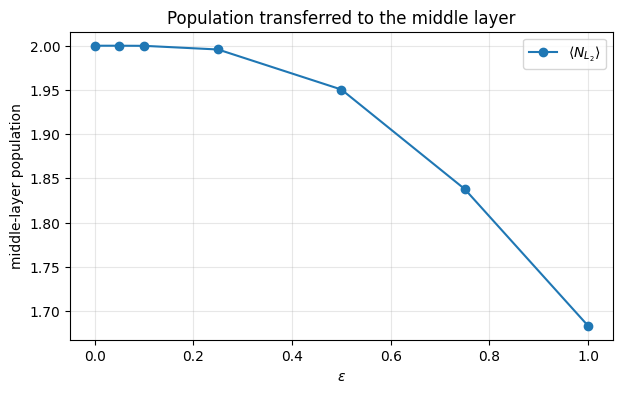

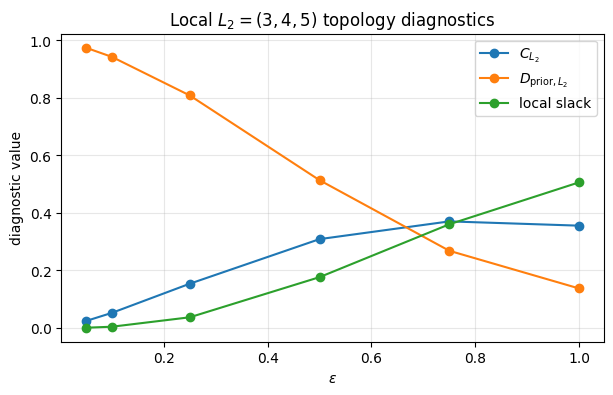

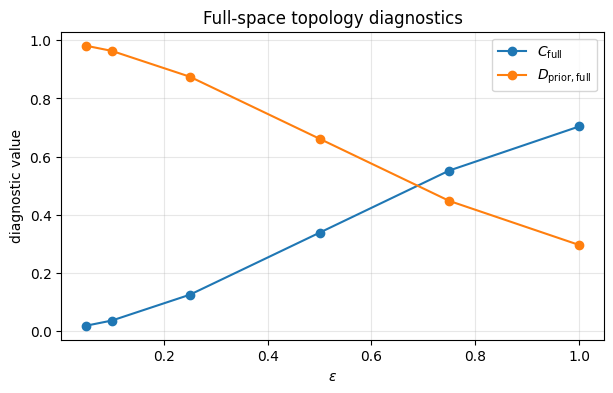

In [73]:
import matplotlib.pyplot as plt

eps_arr = np.array([res["eps"] for res in sweep_232], dtype=float)

L2_occ = np.array([res["layer_occupations"][1] for res in sweep_232], dtype=float)

C_L2 = np.array([
    safe_get(res["details_L2"]["summary"], "C")
    for res in sweep_232
], dtype=float)

Dprior_L2 = np.array([
    safe_get(res["details_L2"]["summary"], "D_prior_population_imbalance")
    for res in sweep_232
], dtype=float)

slack_L2 = np.array([
    safe_get(res["details_L2"]["summary"], "slack")
    for res in sweep_232
], dtype=float)

C_full = np.array([
    safe_get(res["details_full"]["summary"], "C")
    for res in sweep_232
], dtype=float)

Dprior_full = np.array([
    safe_get(res["details_full"]["summary"], "D_prior_population_imbalance")
    for res in sweep_232
], dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(eps_arr, L2_occ, marker="o", label=r"$\langle N_{L_2}\rangle$")
plt.xlabel(r"$\epsilon$")
plt.ylabel("middle-layer population")
plt.title("Population transferred to the middle layer")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(eps_arr, C_L2, marker="o", label=r"$C_{L_2}$")
plt.plot(eps_arr, Dprior_L2, marker="o", label=r"$D_{\mathrm{prior},L_2}$")
plt.plot(eps_arr, slack_L2, marker="o", label=r"local slack")
plt.xlabel(r"$\epsilon$")
plt.ylabel("diagnostic value")
plt.title(r"Local $L_2=(3,4,5)$ topology diagnostics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(eps_arr, C_full, marker="o", label=r"$C_{\mathrm{full}}$")
plt.plot(eps_arr, Dprior_full, marker="o", label=r"$D_{\mathrm{prior,full}}$")
plt.xlabel(r"$\epsilon$")
plt.ylabel("diagnostic value")
plt.title("Full-space topology diagnostics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [74]:
# ============================================================
# Experiment 2: fixed topology, sweep ancilla coupling chi
# ============================================================

from scipy.sparse import identity, kron, csr_matrix
from scipy.sparse.linalg import expm_multiply
import matplotlib.pyplot as plt

def pauli_z_on_qubit(num_qubits, q):
    """
    Sparse operator Z_q on num_qubits qubits.
    q is 0-indexed and follows the same tensor order as:
        |a0> ⊗ |a1> ⊗ ... ⊗ |a_{num_qubits-1}>
    """
    ops = []
    for i in range(num_qubits):
        if i == q:
            ops.append(sigma_z)
        else:
            ops.append(identity_qubit)

    out = ops[0]
    for op in ops[1:]:
        out = kron(out, op, format="csr")
    return out


def build_dispersion_hamiltonian_232(
    hs,
    monitored_modes=(3, 4, 5),
    num_ancillas=3,
):
    """
    Build the chi-free dispersive Hamiltonian:

        H_disp_base = sum_i n_{mode_i} ⊗ Z_i

    The actual Hamiltonian is chi * H_disp_base.
    """
    dim_ancilla = 2 ** num_ancillas
    H_disp = csr_matrix(
        (hs.dim * dim_ancilla, hs.dim * dim_ancilla),
        dtype=complex,
    )

    for q, mode in enumerate(monitored_modes):
        n_mode = hs.hop(mode, mode)
        Z_q = pauli_z_on_qubit(num_ancillas, q)
        H_disp += kron(n_mode, Z_q, format="csr")

    return H_disp


def prepare_232_after_hop(
    eps=0.5,
    hs=hs_232,
    psi_full0=psi_full0_232,
    dim_ancilla=dim_anc_232,
    J=1.0,
    time_method="rms",
):
    """
    Prepare the fixed incoming state after the topology-defined hop.
    This is held fixed during the chi sweep.
    """
    edges = edges12_232_eps(eps, J=J)
    K = K12_232_eps(eps, J=J)
    t1, svals = choose_time_from_K(K, method=time_method)

    H12 = build_H_edges(hs, edges)
    H12_full = kron(
        H12,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )

    psi_after_hop = expm_multiply(
        (-1j * t1) * H12_full,
        psi_full0,
    )

    return {
        "eps": eps,
        "K": K,
        "t1": t1,
        "singular_values": svals,
        "psi_after_hop": psi_after_hop,
    }


def run_232_chi_point(
    chi,
    psi_after_hop,
    H_disp_base,
    hs=hs_232,
    dim_ancilla=dim_anc_232,
    t_int=1.0,
    p_tol=1e-14,
):
    """
    Apply dispersive ancilla interaction at fixed t_int and coupling chi,
    then compute local and full WP diagnostics.
    """
    psi_after_int = expm_multiply(
        (-1j * chi * t_int) * H_disp_base,
        psi_after_hop,
    )

    diag_L2 = wp_layer_diagnostic(
        psi_full=psi_after_int,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(3, 4, 5),
        p_tol=p_tol,
    )

    diag_full = wp_layer_diagnostic(
        psi_full=psi_after_int,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(1, 2, 3, 4, 5, 6, 7),
        p_tol=p_tol,
    )

    details_L2 = decompose_duality_details(
        rho=diag_L2["rho_layer"],
        ancilla_states=diag_L2["conditioned_ancilla_states"],
        probs=diag_L2["probabilities"],
        configs=diag_L2["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    details_full = decompose_duality_details(
        rho=diag_full["rho_layer"],
        ancilla_states=diag_full["conditioned_ancilla_states"],
        probs=diag_full["probabilities"],
        configs=diag_full["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    return {
        "chi": chi,
        "theta": chi * t_int,
        "psi_after_int": psi_after_int,
        "diag_L2": diag_L2,
        "diag_full": diag_full,
        "details_L2": details_L2,
        "details_full": details_full,
    }


def summarize_chi_sweep(results):
    print(
        f"{'chi':>8} {'theta':>8} "
        f"{'C_L2':>10} {'Dprior_L2':>12} {'Ddet_L2':>10} {'slack_L2':>10} "
        f"{'C_full':>10} {'Dprior_full':>13} {'Ddet_full':>11} {'slack_full':>11}"
    )

    for res in results:
        sL = res["details_L2"]["summary"]
        sF = res["details_full"]["summary"]

        print(
            f"{res['chi']:8.4f} {res['theta']:8.4f} "
            f"{sL['C']:10.4f} "
            f"{sL['D_prior_population_imbalance']:12.4f} "
            f"{sL['D_detector_from_fidelity_loss']:10.4f} "
            f"{sL['slack']:10.4f} "
            f"{sF['C']:10.4f} "
            f"{sF['D_prior_population_imbalance']:13.4f} "
            f"{sF['D_detector_from_fidelity_loss']:11.4f} "
            f"{sF['slack']:11.4e}"
        )

In [76]:
# Fixed topology and hopping time
eps_fixed = 0.5
t_int_fixed = 1.0

prep_232 = prepare_232_after_hop(
    eps=eps_fixed,
    hs=hs_232,
    psi_full0=psi_full0_232,
    dim_ancilla=dim_anc_232,
)

psi_after_hop_fixed = prep_232["psi_after_hop"]

H_disp_base_232 = build_dispersion_hamiltonian_232(
    hs=hs_232,
    monitored_modes=(3, 4, 5),
    num_ancillas=3,
)

print("eps fixed:", prep_232["eps"])
print("t1 fixed:", prep_232["t1"])
print("singular values:", prep_232["singular_values"])
print("t_int fixed:", t_int_fixed)

eps fixed: 0.5
t1 fixed: 1.4049629462081452
singular values: [1.22474487 1.        ]
t_int fixed: 1.0


In [81]:
chi_values = np.linspace(0.0, 2.0, 21)

chi_sweep_232 = []

for chi in chi_values:
    res = run_232_chi_point(
        chi=chi,
        psi_after_hop=psi_after_hop_fixed,
        H_disp_base=H_disp_base_232,
        hs=hs_232,
        dim_ancilla=dim_anc_232,
        t_int=t_int_fixed,
    )
    chi_sweep_232.append(res)

summarize_chi_sweep(chi_sweep_232)

     chi    theta       C_L2    Dprior_L2    Ddet_L2   slack_L2     C_full   Dprior_full   Ddet_full  slack_full
  0.0000   0.0000     0.3091       0.5140     0.0000     0.1769     0.3386        0.6614      0.0000  0.0000e+00
  0.1000   0.1000     0.3045       0.5140     0.0065     0.1750     0.3342        0.6614      0.0045  7.9439e-09
  0.2000   0.2000     0.2909       0.5140     0.0256     0.1695     0.3211        0.6614      0.0175  7.0667e-09
  0.3000   0.3000     0.2695       0.5140     0.0558     0.1607     0.3004        0.6614      0.0382  6.8752e-09
  0.4000   0.4000     0.2420       0.5140     0.0949     0.1490     0.2736        0.6614      0.0650  6.6663e-09
  0.5000   0.5000     0.2106       0.5140     0.1403     0.1351     0.2425        0.6614      0.0962  5.3595e-09
  0.6000   0.6000     0.1774       0.5140     0.1890     0.1196     0.2090        0.6614      0.1297  4.4983e-09
  0.7000   0.7000     0.1446       0.5140     0.2382     0.1032     0.1751        0.6614      0.

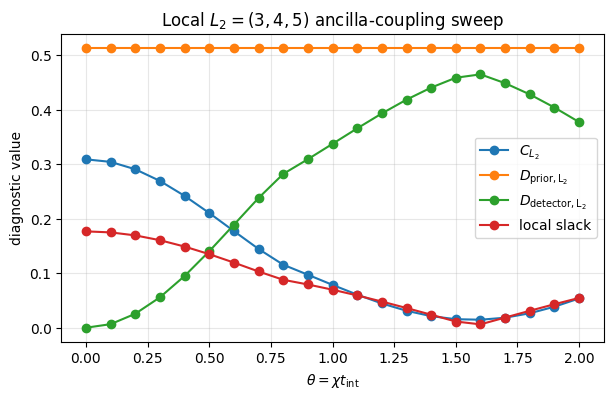

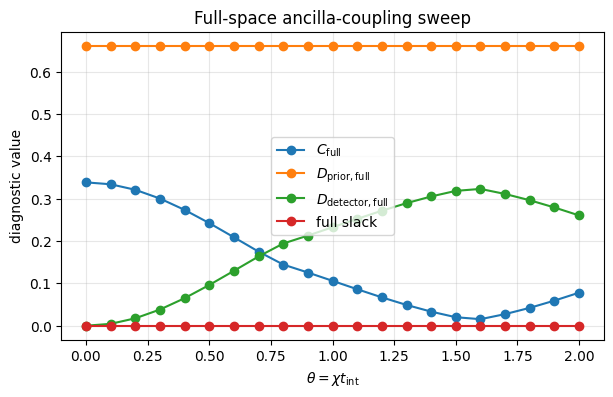

In [82]:
chi_arr = np.array([res["chi"] for res in chi_sweep_232])
theta_arr = np.array([res["theta"] for res in chi_sweep_232])

C_L2 = np.array([res["details_L2"]["summary"]["C"] for res in chi_sweep_232])
Dprior_L2 = np.array([res["details_L2"]["summary"]["D_prior_population_imbalance"] for res in chi_sweep_232])
Ddet_L2 = np.array([res["details_L2"]["summary"]["D_detector_from_fidelity_loss"] for res in chi_sweep_232])
slack_L2 = np.array([res["details_L2"]["summary"]["slack"] for res in chi_sweep_232])

C_full = np.array([res["details_full"]["summary"]["C"] for res in chi_sweep_232])
Dprior_full = np.array([res["details_full"]["summary"]["D_prior_population_imbalance"] for res in chi_sweep_232])
Ddet_full = np.array([res["details_full"]["summary"]["D_detector_from_fidelity_loss"] for res in chi_sweep_232])
slack_full = np.array([res["details_full"]["summary"]["slack"] for res in chi_sweep_232])

plt.figure(figsize=(7, 4))
plt.plot(theta_arr, C_L2, marker="o", label=r"$C_{L_2}$")
plt.plot(theta_arr, Dprior_L2, marker="o", label=r"$D_{\rm prior,L_2}$")
plt.plot(theta_arr, Ddet_L2, marker="o", label=r"$D_{\rm detector,L_2}$")
plt.plot(theta_arr, slack_L2, marker="o", label=r"local slack")
plt.xlabel(r"$\theta=\chi t_{\rm int}$")
plt.ylabel("diagnostic value")
plt.title(r"Local $L_2=(3,4,5)$ ancilla-coupling sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(theta_arr, C_full, marker="o", label=r"$C_{\rm full}$")
plt.plot(theta_arr, Dprior_full, marker="o", label=r"$D_{\rm prior,full}$")
plt.plot(theta_arr, Ddet_full, marker="o", label=r"$D_{\rm detector,full}$")
plt.plot(theta_arr, slack_full, marker="o", label=r"full slack")
plt.xlabel(r"$\theta=\chi t_{\rm int}$")
plt.ylabel("diagnostic value")
plt.title("Full-space ancilla-coupling sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
# ============================================================
# Small-theta ancilla Y-readout diagnostic
# ============================================================

pauli_X = np.array([[0, 1], [1, 0]], dtype=complex)
pauli_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
pauli_Z = np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)


def dense_op_on_qubit(num_qubits, q, op):
    """
    Dense operator acting with op on qubit q and identity elsewhere.
    q is 0-indexed.
    """
    ops = [op if i == q else id2 for i in range(num_qubits)]
    out = ops[0]
    for next_op in ops[1:]:
        out = np.kron(out, next_op)
    return out


def conditioned_ancilla_xyz_table(diag, num_qubits=3, p_tol=1e-14):
    """
    For each active local configuration, compute conditioned ancilla
    expectation values <X_q>, <Y_q>, <Z_q>.
    """
    probs = diag["probabilities"]
    anc_states = diag["conditioned_ancilla_states"]

    rows = []

    X_ops = [dense_op_on_qubit(num_qubits, q, pauli_X) for q in range(num_qubits)]
    Y_ops = [dense_op_on_qubit(num_qubits, q, pauli_Y) for q in range(num_qubits)]
    Z_ops = [dense_op_on_qubit(num_qubits, q, pauli_Z) for q in range(num_qubits)]

    for cfg in diag["active_configs"]:
        if probs[cfg] <= p_tol:
            continue

        rho_A = anc_states[cfg]

        row = {
            "config": cfg,
            "probability": probs[cfg],
        }

        for q in range(num_qubits):
            row[f"X{q+1}"] = float(np.real(np.trace(rho_A @ X_ops[q])))
            row[f"Y{q+1}"] = float(np.real(np.trace(rho_A @ Y_ops[q])))
            row[f"Z{q+1}"] = float(np.real(np.trace(rho_A @ Z_ops[q])))

        rows.append(row)

    return rows


def add_y_readout_estimates(rows, theta, sign=-1.0, num_qubits=3):
    """
    Add estimated occupations from <Y_q>:

        n_hat_q = sign * <Y_q> / (2 theta)

    Use sign=-1 if your convention gives <Y> ≈ -2 theta n.
    Use sign=+1 if your convention gives <Y> ≈ +2 theta n.
    """
    out = []

    for row in rows:
        new_row = dict(row)
        cfg = row["config"]

        sq_error = 0.0
        abs_error = 0.0

        for q in range(num_qubits):
            n_true = cfg[q]
            n_hat = sign * row[f"Y{q+1}"] / (2.0 * theta)

            new_row[f"n{q+1}_true"] = n_true
            new_row[f"n{q+1}_hat"] = n_hat
            new_row[f"n{q+1}_err"] = n_hat - n_true

            sq_error += (n_hat - n_true) ** 2
            abs_error += abs(n_hat - n_true)

        new_row["sq_error"] = sq_error
        new_row["abs_error"] = abs_error
        out.append(new_row)

    return out


def print_y_readout_table(rows, num_qubits=3):
    """
    Compact table comparing true occupations with Y-based estimates.
    """
    header = f"{'config':>12} {'p':>10}"
    for q in range(num_qubits):
        header += f" {'Y'+str(q+1):>9} {'n'+str(q+1)+'_hat':>9}"
    header += f" {'sq_err':>10}"
    print(header)

    for row in rows:
        line = f"{str(row['config']):>12} {row['probability']:10.6f}"
        for q in range(num_qubits):
            line += f" {row[f'Y{q+1}']:9.4f} {row[f'n{q+1}_hat']:9.4f}"
        line += f" {row['sq_error']:10.4e}"
        print(line)

In [86]:
target_theta = 0.1

idx = int(np.argmin(np.abs(theta_arr - target_theta)))
res_small = chi_sweep_232[idx]
theta_small = res_small["theta"]

diag_L2_small = res_small["diag_L2"]

rows_xyz = conditioned_ancilla_xyz_table(
    diag=diag_L2_small,
    num_qubits=3,
)

rows_readout = add_y_readout_estimates(
    rows=rows_xyz,
    theta=theta_small,
    sign=-1.0,
    num_qubits=3,
)

print("theta used:", theta_small)
print_y_readout_table(rows_readout, num_qubits=3)

theta used: 0.1
      config          p        Y1    n1_hat        Y2    n2_hat        Y3    n3_hat     sq_err
   (0, 0, 0)   0.000620    0.0000   -0.0000    0.0000   -0.0000    0.0000   -0.0000 0.0000e+00
   (0, 0, 1)   0.020524    0.0000   -0.0000    0.0000   -0.0000   -0.1987    0.9933 4.4267e-05
   (0, 0, 2)   0.012877    0.0000   -0.0000    0.0000   -0.0000   -0.3894    1.9471 2.7993e-03
   (0, 1, 0)   0.007271    0.0000   -0.0000   -0.1987    0.9933    0.0000   -0.0000 4.4267e-05
   (0, 1, 1)   0.106209    0.0000   -0.0000   -0.1987    0.9933   -0.1987    0.9933 8.8534e-05
   (0, 2, 0)   0.053104    0.0000   -0.0000   -0.3894    1.9471    0.0000   -0.0000 2.7993e-03
   (1, 0, 0)   0.020524   -0.1987    0.9933    0.0000   -0.0000    0.0000   -0.0000 4.4267e-05
   (1, 0, 1)   0.659786   -0.1987    0.9933    0.0000   -0.0000   -0.1987    0.9933 8.8534e-05
   (1, 1, 0)   0.106209   -0.1987    0.9933   -0.1987    0.9933    0.0000   -0.0000 8.8534e-05
   (2, 0, 0)   0.012877   -0.3894 